# Programing exercise 6: ODE integrators

Due on Monday, 25.05.2026, 20h

## The problem

We will again consider the collective Ising spin-model with a transverse field, as in programming exercise 5, which is governed by the Hamiltonian
$$
H=-\frac{J}{N}S_z^2 - \Omega S_x
$$
with the collective spin operators $S_\alpha = \sum_i \sigma_i^\alpha/2$, where $\sigma_i^\alpha$ is a Pauli operator acting on spin $i$. We studied this model in detail on the previous exercise sheet using exact diagonalization. Now we want to test how different numerical integrators perform on this problem and use exact diagonalziation as a benchmark.

In [1]:
# load standard libraries

import numpy as np   # standard numerics library
import numpy.linalg as LA
from scipy.integrate import ode


import matplotlib.pyplot as plt   # for making plots

import time as time

import scipy.sparse as sparse
import scipy.sparse.linalg as sLA

import Comp_Quant_Dynam as cqd

### Exact diagonalization code

Here is an example implemetation of the exact diagonalization which we will use as a reference for obtaining the error of the numerical integration schemes we will implement.

Definitions for building the Hamiltonian

Here we define a function that calculates the time evolution using exact diagonalization. This will be used to benchmark the performance of the numerical integrators.

In [2]:
dtout = 0.1
tend = 10
tsteps = int(np.round(tend/dtout))
tvec_output = np.linspace(0,dtout*tsteps,tsteps+1)

ome = 0.6 # use this throughout

N = 100
ini = np.eye(N+1)[0] # initial state will always be |1...1>

### Exercise 1

Now we want to use different integrators to see how they perform. A code for testing the Euler method has already been implemeted for you. Run it and describe your observations. Play with the step size in the 1st part.

In this exercise you don't need to code but just understand the given code and play with it.

Overall, you should try to answer the following questions:
- How does the global error of Euler scale with dt?
- What dt is needed to obtain $S_x$ at $t=10$ with an absolute error of less than 0.1?
- How does the norm grow in time? What does this tell us about stability?
- How do the deviations from the exact solution behave for the different observables? Oscillate around the exact value of deviate from it monotonically?
- How does the stability depend on the atom number? How can we interpret this in terms of the stiffness of the problem?

Here are some functions that will allow us to make the code for testing the integrators quite compact and avoid too much redundancy.

Calculate ED result.

In [3]:
dtout = 0.1
tend = 10
tsteps = int(np.round(tend / dtout))
tvec_output = np.linspace(0, dtout * tsteps, tsteps + 1)
#tvec_output = tvec_ED
ome = 0.6

N = 20
ini = np.eye(1, N + 1, 0)[0]

# set up observables and Hamiltonian
Sz = cqd.operators.Sz_sparse(N)
Sx = cqd.operators.Sx_sparse(N)
S_eye = sparse.identity(N+1, format='csr')
obsv_vec = [Sz, Sx, S_eye]

H_mat = cqd.hamiltonians.build_H_TFIM(N, ome)

observables_ED = cqd.unitaries.calc_expv_ED(obsv_vec, H_mat, ini, tvec_output)

time for ED was 0.008846759796142578


Intergration with Euler:

Integrate with a given step size to study accuracy.

time for integration was 0.03197455406188965


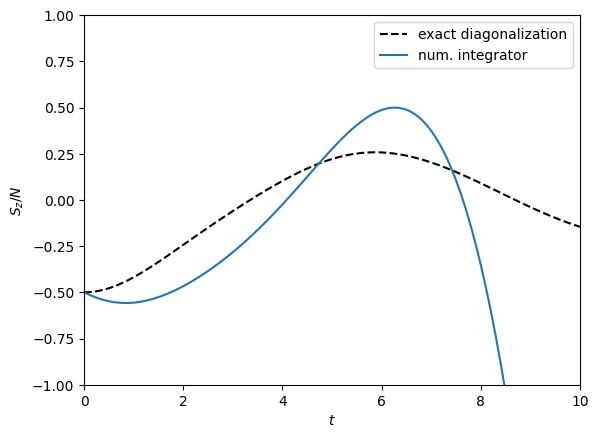

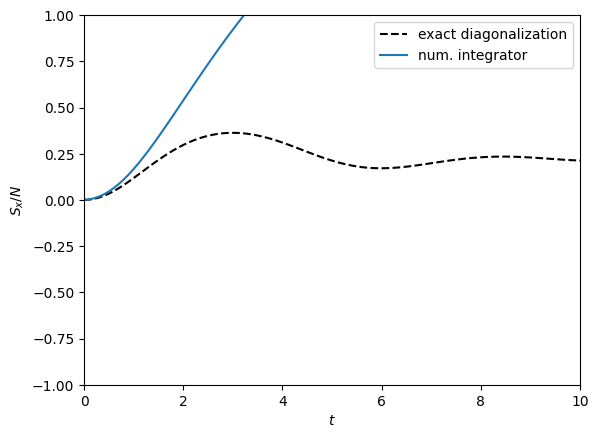

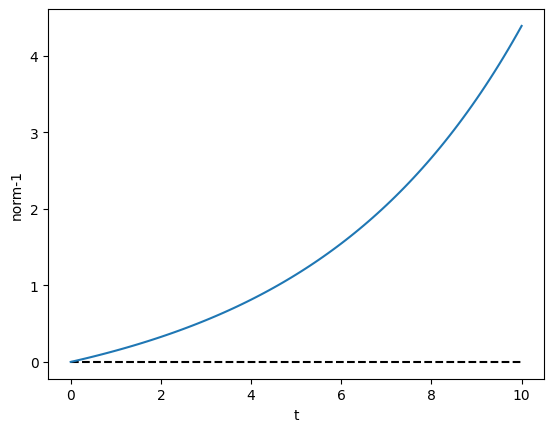

In [4]:
# choose integrator and time step
stepper_func = cqd.integrators.Euler_step
stepper_args = []

int_steps_per_dtout = 10

# integration
observables_Integrator = cqd.integrators.integrate_ODE(stepper_func, obsv_vec, H_mat, ini, tvec_output, int_steps_per_dtout, stepper_args)

# plotting
cqd.plotting.plot_compare_ED(N, observables_Integrator, observables_ED, tvec_output)

Next we want to loop over step size to see how error depends on it.

In [5]:
# in each iteration, divide the step size by some factor
red_factor = 2 # must be integer in this implementation
n_red_step = 11
stepper = cqd.integrators.Euler_step
stepper_args = []

deviations, step_sizes = cqd.integrators.loop_time_step(stepper, obsv_vec, H_mat, ini, tvec_output, red_factor, n_red_step, stepper_args)

time for ED was 0.030391454696655273
dt_integrator =  0.1
time for integration was 0.02380537986755371
dt_integrator =  0.05
time for integration was 0.020597219467163086
dt_integrator =  0.025
time for integration was 0.017239809036254883
dt_integrator =  0.0125
time for integration was 0.017891883850097656
dt_integrator =  0.00625
time for integration was 0.0712594985961914
dt_integrator =  0.003125


/home/niklas/PhD/Code/CQD_SS26/Comp_Quant_Dynam/integrators.py:47: UserWarning: Some observables have non-zero imaginary parts
  warnings.warn("Some observables have non-zero imaginary parts")


time for integration was 0.13787436485290527
dt_integrator =  0.0015625
time for integration was 0.17702436447143555
dt_integrator =  0.00078125
time for integration was 0.2517969608306885
dt_integrator =  0.000390625
time for integration was 0.4282841682434082
dt_integrator =  0.0001953125
time for integration was 0.8882801532745361
dt_integrator =  9.765625e-05
time for integration was 1.5157544612884521


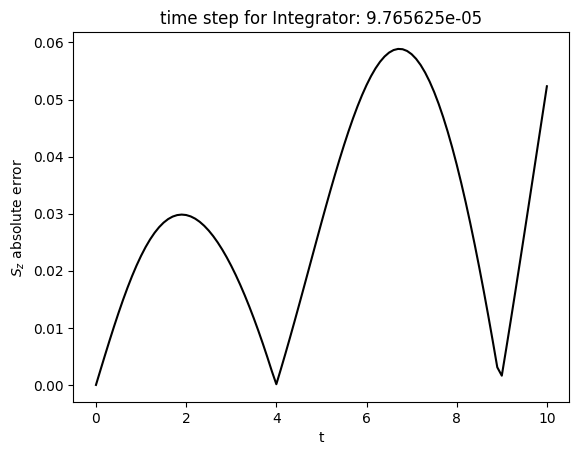

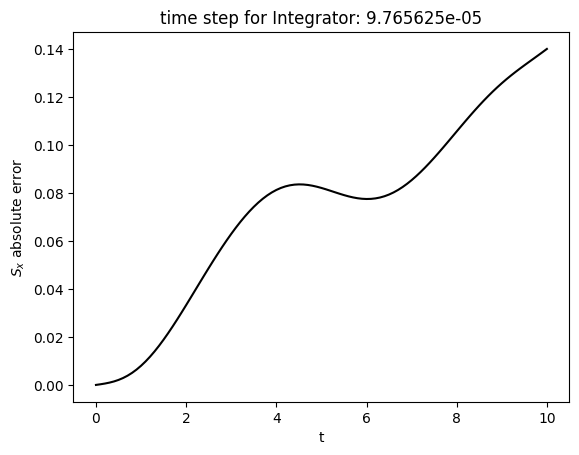

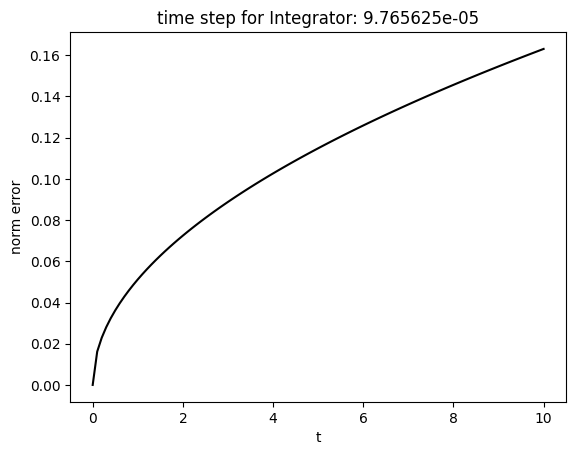

In [6]:
idx_stepsize = -1

cqd.plotting.plot_deviations(idx_stepsize, deviations, tvec_output, step_sizes)

Plot deviation as function of step size. Use a double log scale.

Here, use the deviation of $S_x$ at the end time as an indicator for accuracy. One could also use other observables. If an observable oscillates in time around the exact value, it is better to use a time average over some time interval to quantify the error.

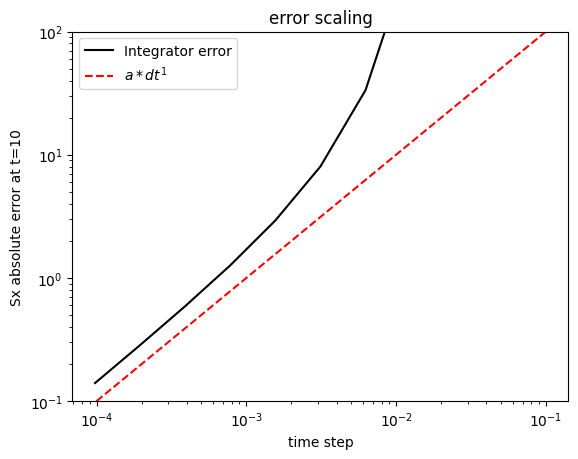

In [7]:
plt.loglog(step_sizes, deviations[:, 1, -1], 'k') # plot the error at the final time for Sx ([:, 1, -1]) as a function of the time step size on a log-log scale
plt.loglog(step_sizes,10 ** 3 * step_sizes, 'r--') # linear scaling for comparison (the prefactor 10**3 is just to make the line visible in the plot, you can adjust it as needed)
plt.title('error scaling')
plt.ylim([10 ** -1, 10 ** 2]) # Euler N=20
plt.legend(['Integrator error','$a*dt^1$'])
plt.xlabel('time step')
plt.ylabel('Sx absolute error at t=10')
plt.show()

### Exercise 2

Do a corresponding analysis for other integrators (specified below). Discuss your observations as above. All you need to change is the stepper function. What is the scaling of the error with the time step? Is the norm conserved?

Try the Crank Nicolson integrator, which is an implicit integrator. The scipy function `spsolve()` may be useful.

Implement and try out the Arnoldi integrator. A function that calculates the Krylov vectors and the Hamiltonian in Krylov space has been implemented for you already in `cqd.integrators.generate_krylov_subspace()`. A good refernce on the details of this is https://www.sciencedirect.com/science/article/pii/S0010465598000836
The wikipadia page on the Arnoldi iteration even has a python source code for constructing the Krylov vectors.
Typical values for the intergation order are $n=10...20$. As the evolution within Krylov space is not the bottleneck in terms of runtime (the construction of the Krylov vectors is much more costly for large Hilber space dimension), it is ok to use `expm()` for this.

For these integrators you should use at least $N=100$. With Euler, really tiny steps would be needed to prevent it from diverging in this case, but higher order integrators should do much better.

### Exercise 3

Now we want to use a numerical intergrator from the `scipy.integrate` module. For this I reccomend using the `ode` class which gives the best control of parameters and greatest choice of methods. The documentation is here: https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.ode.html#scipy.integrate.ode

The stepping with `ode` is typically done like this:

`r.integrate(r.t + dt)` <br>
`Psi = r.y`

Try different integrators and options to see how they perform in terms of speed and accuracy. Use a fixed particle number of N=100. Describe your observations. Example options are given below. Try to find something faster/more stable!

These integrators all use adaptive stepsize internally, so we don't have to analyze the step size dependence of the accuracy. They should in principle always give accurate results or otherwise give a warning message that the specified accuracy goal could not be reached.

In [8]:
# initialize the integrator

y0, t0 = ini, 0

r = ode(cqd.integrators.schroedinger_diff_eq).set_integrator('zvode', method='adams', with_jacobian=False)
r.set_initial_value(y0, t0).set_f_params(H_mat)

### Exercise 4 (optional)

Next, we want to check how the runtime for integrating our ODE scales with the number of spins N (or equivalently the Hilbert space dimension) and compare this to ED. Below is a code where you have to insert only your numerical integrator initialization and stepping.

For me, ED was still faster for up to `N=1000` even compared to Arnoldi. Challenge: Try to find an integrator that beats my ED implementation :-)

Describe and interpret your observations. Play with step size and integrator order. Make sure that for the chosen integration step size the results are still accurate. (Eventually one would of course include an adaptive stepsize such that the local error is controlled!)

You can also try odeint (https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.odeint.html#scipy.integrate.odeint) and/or solve_ivp (https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html#scipy.integrate.solve_ivp). These modules are less object oriented and have a restricted choice of integrators but are somewhat easier to use. 

All the documentation pages have a lot of useful information about the integrators and even links to the original publications in which they were introduced.

In [9]:
# Compare ED to scipy.integrate.ode

dt = 0.1
tend = 10
tsteps = int(np.round(tend / dt))
tvec = np.linspace(0, dt * tsteps, tsteps + 1)

ome = 0.6

# running it to N=2000 takes a few minutes and starts to use significant memory (for testing, reduce this!)
#N_vals = np.arange(200, 2001, 100) 
N_vals = np.arange(200, 501, 100) 


observables = np.zeros((4, len(tvec), len(N_vals))) # for storing the results for Sz and Sx for both methods
runtimes = np.zeros((3, len(N_vals))) # store time for H buildup, ED, and numerical integration

for idx_N, N in enumerate(N_vals):
    
    print("N = ", N)
    ini = np.eye(1, N + 1, 0)[0]
    
    t1=time.time()
    
    Sz = cqd.operators.Sz_sparse(N)
    Sx = cqd.operators.Sx_sparse(N)
    obsv_vec = [Sz, Sx]
    H_mat =cqd.hamiltonians.build_H_TFIM(N, ome)
    
    t2=time.time()
    runtimes[0,idx_N] = t2-t1 # time for H matrix buildup, should be negligible

    # ED solution
    t1=time.time()
    observables_ED = cqd.unitaries.calc_expv_ED(obsv_vec, H_mat, ini, tvec)
    # think about 
    
    t2=time.time()
    runtimes[1,idx_N] = t2-t1 # time for ED
    
    # store observables (for checking accuracy)
    observables[:2, :, idx_N] = observables_ED
    #observables[1, :, idx_N] = observables_ED[1,:]
    
    # integrator solution
    t1=time.time() # start run time measurement
   
    # set up the integrator
    ### CODE HERE
    
    # do the integration
    ### CODE HERE. Should produce an array observables_Integrator

    t2=time.time() # end run time measurement
    runtimes[2,idx_N] = t2-t1 # time for integration
    
    # store observables (for checking accuracy)
    # observables[2:, :, idx_N] = observables_Integrator

N =  200
time for ED was 0.3362247943878174
N =  300
time for ED was 0.07042431831359863
N =  400
time for ED was 0.10683536529541016
N =  500
time for ED was 0.14798951148986816


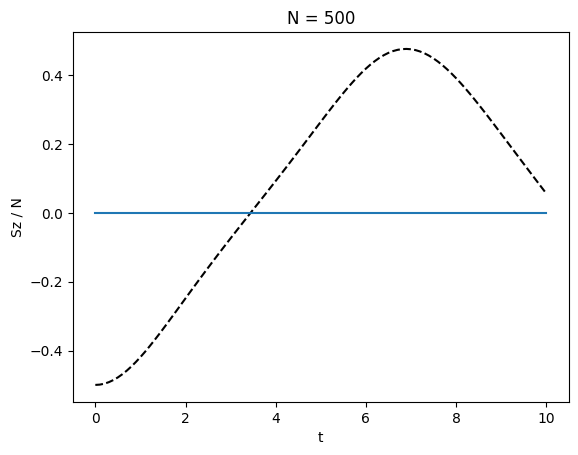

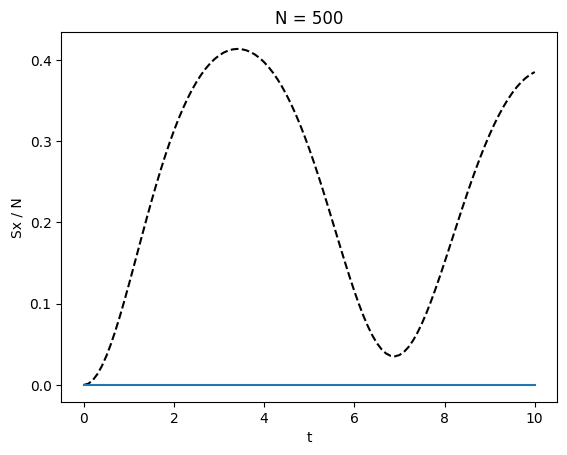

In [10]:
# plotting observables to check that integration was converged and accurate
idx_N = -1
plt.plot(tvec, observables[0,:,idx_N] / N_vals[idx_N], 'k--')
plt.plot(tvec, observables[2,:,idx_N] / N_vals[idx_N])
plt.title('N = '+ str(N_vals[idx_N]))
plt.xlabel('t')
plt.ylabel('Sz / N')
plt.show()

plt.plot(tvec,observables[1, :, idx_N] / N_vals[idx_N], 'k--')
plt.plot(tvec,observables[3, :, idx_N] / N_vals[idx_N])
plt.title('N = '+ str(N_vals[idx_N]))
plt.xlabel('t')
plt.ylabel('Sx / N')
plt.show()

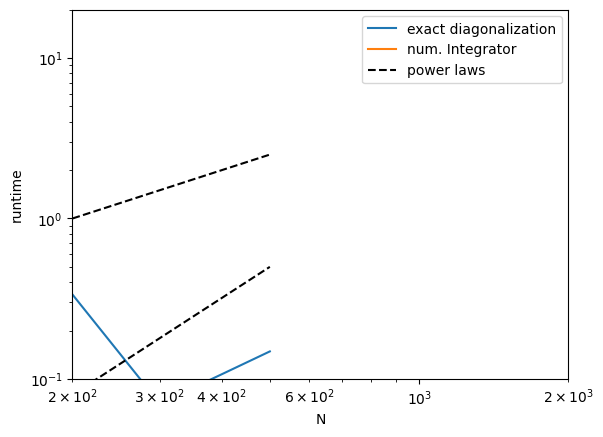

In [11]:
# plotting N-dependence of runtimes
plt.loglog(N_vals, runtimes[1])
plt.loglog(N_vals, runtimes[2])
plt.loglog(N_vals, 0.005 * N_vals, 'k--')
plt.loglog(N_vals, 2 * 10 ** -6 * N_vals ** 2,'k--')
plt.ylim([10 ** -1, 2 * 10 ** 1])
plt.xlim([2 * 10 ** 2, 2 * 10 ** 3])
plt.ylabel('runtime')
plt.xlabel('N')
plt.legend(['exact diagonalization','num. Integrator','power laws'])
plt.show()